# Analysing LiTS dataset

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from idssp.sonk.view import utils
from idssp.sonk.model.data import DataWrapper, VolumeWrapper
from idssp.sonk.model.training import ModelBuilder
from idssp.sonk import config

from IPython.display import HTML

Importing torch... (This may take a moment)
🚀 Loading configuration for environment: [LOCAL]
⚠️  Running in LOCAL environment.
   Device: cpu
   Batch Size: 1
   Workers: 0
   Data Root: /media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1
   Checkpoint Dir: checkpoints


## Extracting the images

In [ ]:
wrapper = DataWrapper(config.LITS_ROOT, IMG_PREFIX, MASK_PREFIX, SUFFIX)

VOLUMES_TO_ANALYSE = [2, 3]

Importing torch... (This may take a moment)
🚀 Loading configuration for environment: [LOCAL]
⚠️  Running in LOCAL environment.
   Device: cpu
   Batch Size: 1
   Workers: 0
   Data Root: /media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1
   Checkpoint Dir: checkpoints


In [6]:
wrapper.set_volume(VOLUMES_TO_ANALYSE[0])

Loading data for volume 2...
Data loaded successfully.
Calculating unique values in the label data...
Finding slice information...
done!


In [7]:
wrapper.print_summary_of_volume()

Volume 2 summary:
--------------------File paths--------------------
Image path: /media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/volume-2.nii
Label path: /media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/segmentation-2.nii
--------------------File shapes--------------------
Image shape: (512, 512, 517)
Label shape: (512, 512, 517)
--------------------Data arrays--------------------
Image data shape: (512, 512, 517)
Mask data shape: (512, 512, 517)
--------------------- value ranges--------------------
CT intensity range: -1024.0 to 3071.0
Mask intensity range: 0 to 2
Voxel dimensions (mm): (np.float32(0.7753906), np.float32(0.7753906), np.float32(1.0))
--------------------Affine information--------------------
Image affine transformation matrix:
 [[-7.75390625e-01  0.00000000e+00  0.00000000e+00  1.99112305e+02]
 [ 0.00000000e+00  7.75390625e-01  0.00000000e+00 -2.71123047e+01]
 [ 0.00000000e+00  0.00000000e+00  1.

## Visualising the data

Plotting slice 449 of volume 2...


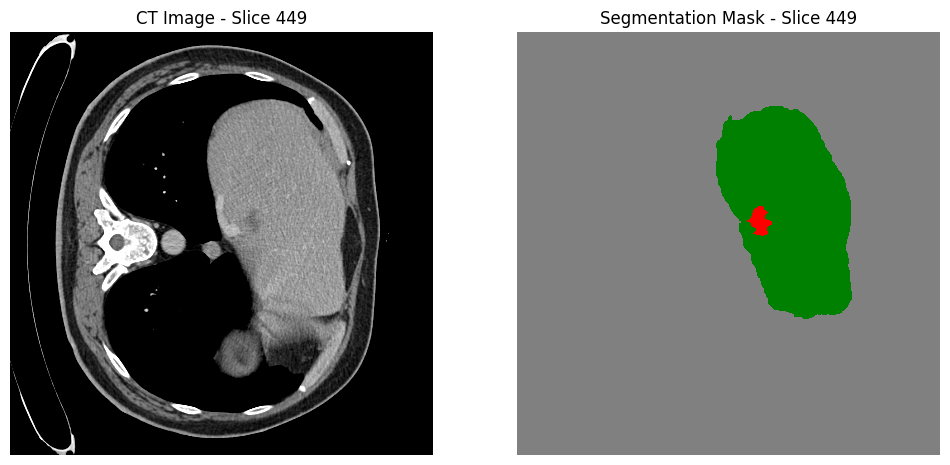

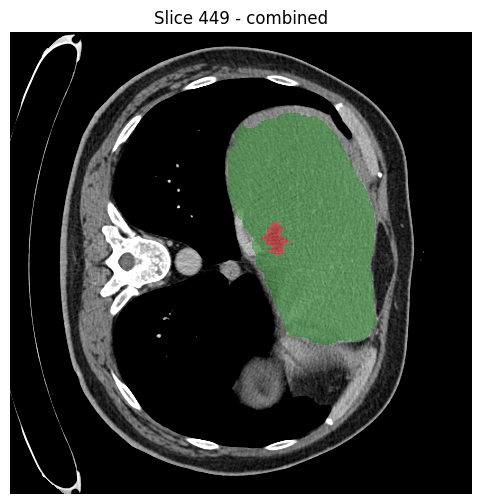

In [8]:
wrapper.plot_slice(449)

The following cell takes too much space, so just run it
locally

In [25]:
# HTML(wrapper.get_animation_motion().to_jshtml())

In [9]:
utils.slice_to_world_coordinates(wrapper.volume.image, wrapper.volume.slice_thresholds['liver']['first'])

np.float64(-780.0999755859375)

## Model training

In [10]:
import torch
import torch.optim as optim
from monai.networks.nets import UNet
from monai.losses import DiceLoss

### Data loading

In [11]:
# Get the file paths
train_files = []
val_files = []

train_files.append(wrapper.get_paths_of_volume(VOLUMES_TO_ANALYSE[0]))
val_files.append(wrapper.get_paths_of_volume(VOLUMES_TO_ANALYSE[1]))

print("Training files:")
for file in train_files:
    print(file)

print("Validation files:")
for file in val_files:
    print(file)

Training files:
{'image': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/volume-2.nii', 'label': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/segmentation-2.nii'}
Validation files:
{'image': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/volume-3.nii', 'label': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/segmentation-3.nii'}


In [12]:
builder = ModelBuilder()

builder.init_data_loaders(train_files, val_files)

ModelBuilder initialized. Device set to: cpu
Creating training transforms object...
Creating validation transforms object...
Initializing training dataset...
Initializing validation dataset...
Creating training dataloader...
Creating validation dataloader...
Data loaders initialized successfully.


### Modelling

It's gonna be a basic UNet

In [13]:
builder.init_model()

Initializing model...


### Training

In [ ]:
# start small, increase later
builder.train(10)

Epoch 1/10
